<a href="https://colab.research.google.com/github/NehaSusan14/6THSEM-ML-LAB/blob/main/LAB6SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9722222222222222

Saving iris (1).csv to iris (1) (2).csv
Dataset Preview:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


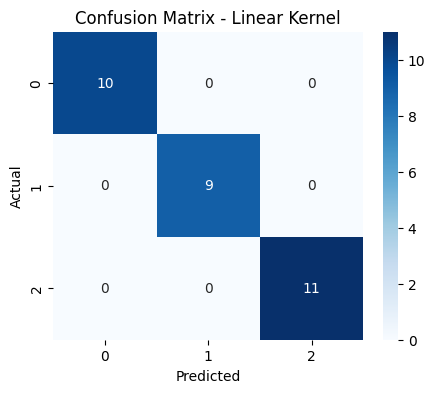


RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


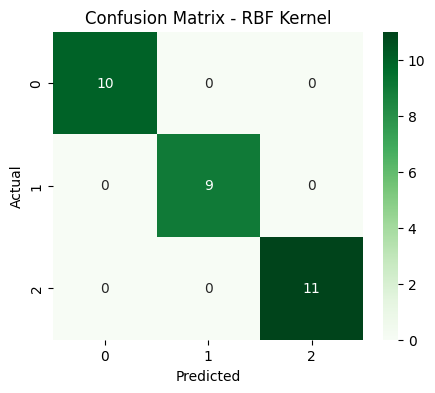

In [ ]:
# Upload Iris dataset
from google.colab import files
import io # Import io module for handling uploaded file content

uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the filename of the uploaded file
# Assuming only one file is uploaded, take the first key from the 'uploaded' dictionary
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    # Load dataset using the content of the uploaded file
    data = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]))
else:
    raise ValueError("No file was uploaded. Please upload the 'iris.csv' file.")

# Display first rows
print("Dataset Preview:")
print(data.head())

# Split features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# -----------------------------
# SVM with Linear Kernel
# -----------------------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
cm_linear = confusion_matrix(y_test, y_pred_linear)

print("\nLinear Kernel Accuracy:", acc_linear)
print("Confusion Matrix (Linear):\n", cm_linear)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_linear, annot=True, cmap='Blues')
plt.title("Confusion Matrix - Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# SVM with RBF Kernel
# -----------------------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("\nRBF Kernel Accuracy:", acc_rbf)
print("Confusion Matrix (RBF):\n", cm_rbf)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_rbf, annot=True, cmap='Greens')
plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Upload dataset
from google.colab import files
import io # Import io module for handling uploaded file content
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
# Get the filename of the uploaded file
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    # Check the file extension and read accordingly
    if uploaded_filename.endswith('.csv'):
        data = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]), header=None)
    elif uploaded_filename.endswith('.xlsx'):
        data = pd.read_excel(io.BytesIO(uploaded[uploaded_filename]), header=None)
    else:
        raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")
else:
    raise ValueError("No file was uploaded. Please upload the 'letter-recognition.xlsx' file.")

# First column = target letter
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Convert labels to binary format for ROC
classes = sorted(y.unique())
y_bin = label_binarize(y, classes=classes)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM classifier
svm = SVC(kernel='rbf', probability=True)
model = OneVsRestClassifier(svm)
model.fit(X_train, label_binarize(y_train, classes=classes))

# Predictions
y_pred_bin = model.predict(X_test)
y_score = model.predict_proba(X_test)

# Convert binary predictions back to letters
y_pred = [classes[np.argmax(row)] for row in y_pred_bin]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve and AUC (micro-average)
fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

print("\nAUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Saving letter-recognition.xlsx to letter-recognition (1).xlsx
